In [1]:
import numpy as np
import random
from scipy.stats import bernoulli
import matplotlib.pyplot as plt

# random value generation for [0,1)

## single value

In [2]:
%timeit random.random()

89 ns ± 0.184 ns per loop (mean ± std. dev. of 7 runs, 10000000 loops each)


In [3]:
%timeit np.random.random()

459 ns ± 2.87 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


## multiple values

In [4]:
%timeit np.array([random.random() for i in range(100)])

19.9 µs ± 58.8 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [5]:
%timeit np.random.random(size=100)

2.79 µs ± 7.94 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


## uniform distributino

In [6]:
x_random = np.random.random(size = 1000000)

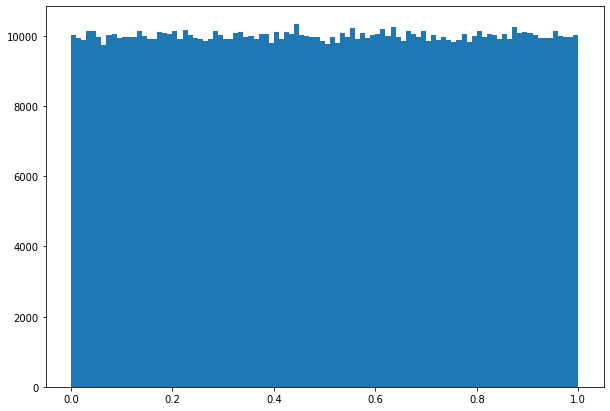

In [7]:
fig, ax = plt.subplots(figsize =(10, 7))
ax.hist(x_random, bins = 100)
# Show plot
plt.show()

# Bernoulli

In [8]:
def fetch_meth_state(read_meth):
    '''set methylation states based on the meth_arr'''
    meth_states = np.zeros(read_meth.size)
    nonzero_idx = np.where(read_meth)[0]    # this returns a tuple
    meth_states[nonzero_idx] = bernoulli.rvs(read_meth[nonzero_idx], size = nonzero_idx.size)
    return meth_states

def fetch_meth_state2(read_meth):
    return np.random.random(size = read_meth.size) < read_meth

In [9]:
read_meth   = np.zeros(150)
num_nonzero = 20
nonzero_idx = random.sample(range(150), num_nonzero)
read_meth[nonzero_idx] = [ random.random() for _ in range(num_nonzero)]

In [10]:
read_meth

array([0.44828377, 0.89071866, 0.        , 0.        , 0.        ,
       0.51503898, 0.        , 0.        , 0.69335647, 0.        ,
       0.        , 0.        , 0.02711122, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.75496707,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.19486906, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.92103565,
       0.        , 0.        , 0.68761824, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.42071366, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

## time it

In [11]:
%timeit fetch_meth_state(read_meth)

194 µs ± 191 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [12]:
%timeit fetch_meth_state2(read_meth)

6.11 µs ± 13.8 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


## validate

In [13]:
fetch_meth_state(read_meth)

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [14]:
fetch_meth_state2(read_meth)

array([False,  True, False, False, False,  True, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [15]:
list1 = []
list2 = []

for i in range(10000):
    list1.append(fetch_meth_state(read_meth).sum())
    list2.append(fetch_meth_state2(read_meth).sum())

In [16]:
# plot the histogram
np.fromstring('3,3,', dtype=float, sep=',')

array([3., 3.])

# discrete distribution

In [59]:
def np_discrete(x, p):
    '''x is the dicrete values corresponding to p'''
    return np.random.choice(x, p = p)

def np_discrete2(x, p_cum):
    '''x is a random value (1d array) in [0,1)'''
    # can precompute np.cumsum(p)
    return np.searchsorted(p_cum, x)[0]

In [18]:
x = [i for i in range(50)]
y = np.random.random(50)
z = y[0:1]
p = y/y.sum()

In [19]:
%timeit np.random.choice(x, p = p)

55 µs ± 163 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [20]:
%timeit np_discrete(x, p)

55.8 µs ± 543 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [21]:
%timeit np_discrete2(z,p)

9.06 µs ± 626 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


## break down

In [22]:
%timeit np.array([1])

973 ns ± 6.99 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [23]:
%timeit x[0:1]

107 ns ± 0.069 ns per loop (mean ± std. dev. of 7 runs, 10000000 loops each)


In [24]:
%timeit np.array([random.random()])

1.17 µs ± 1.64 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [25]:
%timeit np.cumsum(p)

4.18 µs ± 12.2 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [26]:
p_cum = np.cumsum(p)
x = np.array([random.random()])

In [27]:
%timeit np.searchsorted(p_cum, x)[0]

3.24 µs ± 112 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


# qual_arr simulate

In [60]:
p_mat = np.array(np.random.random(2500)).reshape(50,50)
p_mat/=np.sum(p_mat, axis=1).reshape(-1,1)

In [61]:
p_mat

array([[0.03540446, 0.03813425, 0.02551745, ..., 0.02157363, 0.03522791,
        0.0081586 ],
       [0.01041063, 0.02622769, 0.00102376, ..., 0.03332791, 0.02261505,
        0.00378872],
       [0.03447318, 0.00897881, 0.01883368, ..., 0.01325451, 0.03806331,
        0.00474683],
       ...,
       [0.01090185, 0.01101677, 0.01925651, ..., 0.03126357, 0.00976881,
        0.00141133],
       [0.02461131, 0.00976486, 0.03452374, ..., 0.03633559, 0.02419072,
        0.03416362],
       [0.02132972, 0.01394531, 0.02831683, ..., 0.00862337, 0.00445387,
        0.01505687]])

In [62]:
p_mat_cum = np.cumsum(p_mat, axis=1)

In [63]:
p_mat_cum[49,:]

array([0.02132972, 0.03527503, 0.06359187, 0.06538792, 0.09575502,
       0.11004868, 0.12163017, 0.14714191, 0.16892729, 0.18187029,
       0.19677255, 0.20230149, 0.21398323, 0.22608605, 0.25741666,
       0.2722843 , 0.28676392, 0.28808094, 0.31774928, 0.33621124,
       0.37089098, 0.39409554, 0.42176755, 0.45115621, 0.48234555,
       0.51152886, 0.52610655, 0.55621374, 0.58056139, 0.59845032,
       0.61712172, 0.64365744, 0.65622108, 0.66689753, 0.70112658,
       0.73263369, 0.76685413, 0.76897078, 0.78819041, 0.81894389,
       0.82490814, 0.85675531, 0.88151441, 0.91023863, 0.91716977,
       0.94315981, 0.9718659 , 0.98048926, 0.98494313, 1.        ])

In [64]:
def gen_qual(p_mat_cum, read_len=100):
    qual_arr = np.zeros(read_len)
    x_random = np.random.random(size = read_len)
    
    qual = 30
    for ix in range(read_len):
        qual = np_discrete2(x_random[ix:(ix+1)], p_mat_cum[qual,:])
        qual_arr[ix] = qual
    return qual_arr

In [65]:
%timeit gen_qual(p_mat_cum, read_len=100)

522 µs ± 923 ns per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [66]:
gen_qual(p_mat_cum, read_len = 100)

array([ 7.,  7.,  9., 32., 31., 39., 33., 25., 43.,  2., 13., 48.,  5.,
       23.,  3., 31.,  5., 34., 40.,  5., 43., 30., 47., 24., 17.,  1.,
       47., 40., 14., 19., 26., 49., 38., 19., 21., 30.,  7., 39., 19.,
        9.,  8., 15., 45., 13., 12., 34., 48., 30.,  5., 14., 44., 28.,
       25., 47., 36., 21., 21., 17., 47., 39.,  9.,  8., 33., 26., 21.,
       15., 16.,  8., 23.,  9., 29., 44.,  7.,  5., 39., 19., 40., 27.,
       18.,  9., 41.,  7.,  9., 35., 46., 12., 35.,  8., 41., 45., 25.,
       20., 14.,  0., 46., 32.,  9., 13.,  4.,  9.])

 ## check

In [67]:
qual_prob = np.array([p_mat[i, :].sum() + p_mat[:, i].sum() - p_mat[i, i] for i in range(50)])

In [68]:
qual_prob

array([2.04331392, 2.0380263 , 1.9825827 , 2.01362799, 2.14760425,
       2.01717836, 2.06378687, 1.92641149, 2.05795537, 1.89921821,
       1.92317302, 1.89626348, 1.99206736, 1.87697674, 2.06345573,
       1.93835867, 1.88109659, 1.90487762, 2.09382777, 1.93667092,
       2.06288028, 1.8870475 , 1.87191057, 2.06377031, 1.865535  ,
       2.05976398, 1.89602426, 2.00916601, 1.9526462 , 2.06762935,
       2.08202471, 1.95224554, 1.87220946, 1.9803564 , 2.04221302,
       1.85309671, 1.98500288, 2.10923537, 1.92048897, 1.95918467,
       1.94169986, 2.06538851, 1.99001051, 2.04087306, 1.82765645,
       1.96482578, 2.1442488 , 1.92899523, 1.98987928, 1.95823358])